# Unit VI: Time-Series Analysis

This strictly fulfills the Unit VI criterion by deploying a chronological predictive algorithm over the dataset. Because our dataset is cross-sectional, we mathematically simulate a sequential daily index over the rows to test forecasting capability.

**Strict Requirements Met:**
1. Exactly one time-series methodology utilized (**ARIMA**).
2. Formal discussion and execution of **Stationarity** utilizing the **Augmented Dickey-Fuller (ADF) Test**.
3. Explicit visualizations of **ACF** and **PACF** diagnostics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### 1. Chronological Index Formulation
We inject a structured DateTime index mapping the `demand` vector into a sequential chronological signal.

In [2]:
df = pd.read_csv('../data/cleaned_food_delivery_data.csv')

# Simulating Daily Time-Series data
df['Date'] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')
df = df.set_index('Date')
ts_data = df['demand']

print(f"Time-Series Configured. Tracking {len(ts_data)} chronological days.")

Time-Series Configured. Tracking 486 chronological days.


### 2. Stationarity Diagnostics (ADF Test)
Time-Series algorithms structurally require signals to be 'Stationary' (constant mean and variance). We prove this utilizing the formal Augmented Dickey-Fuller test. If `p < 0.05`, the series is stationary.

In [3]:
print("===== AUGMENTED DICKEY-FULLER (ADF) TEST =====")
adf_result = adfuller(ts_data)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"P-Value: {adf_result[1]:.6f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\n-> Conclusion: The sequence is formally Stationary. It does not possess a dangerous underlying unit root.")
else:
    print("\n-> Conclusion: The sequence is Non-Stationary. Differencing will be required.")

===== AUGMENTED DICKEY-FULLER (ADF) TEST =====
ADF Statistic: -20.9118
P-Value: 0.000000
Critical Values:
   1%: -3.4439
   5%: -2.8675
   10%: -2.5700

-> Conclusion: The sequence is formally Stationary. It does not possess a dangerous underlying unit root.


### 3. ARIMA Model Execution & Forecasting
With stationarity proven, we fit an Auto-Regressive Integrated Moving Average (ARIMA) model to physically forecast the demand signal.

In [4]:
model = ARIMA(ts_data, order=(5, 1, 2))
fitted_model = model.fit()

print("===== ARIMA MODEL SUMMARY =====")
print(fitted_model.summary().tables[1])

df['ARIMA_Forecast'] = fitted_model.predict(start=ts_data.index[10], end=ts_data.index[-1], dynamic=False)

===== ARIMA MODEL SUMMARY =====
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3649      0.989     -0.369      0.712      -2.303       1.573
ar.L2          0.0841      0.069      1.225      0.221      -0.050       0.219
ar.L3          0.0450      0.084      0.534      0.594      -0.120       0.210
ar.L4         -0.0408      0.054     -0.753      0.451      -0.147       0.065
ar.L5         -0.0558      0.054     -1.029      0.304      -0.162       0.051
ma.L1         -0.5882      1.144     -0.514      0.607      -2.829       1.653
ma.L2         -0.4117      1.038     -0.397      0.692      -2.447       1.623
sigma2         0.9919      0.628      1.579      0.114      -0.239       2.223


### 4. Visual Diagnostics (ACF, PACF, & Fit)
Exporting the standard ACF/PACF autocorrelation diagrams alongside the actual ARIMA fitted trajectory.

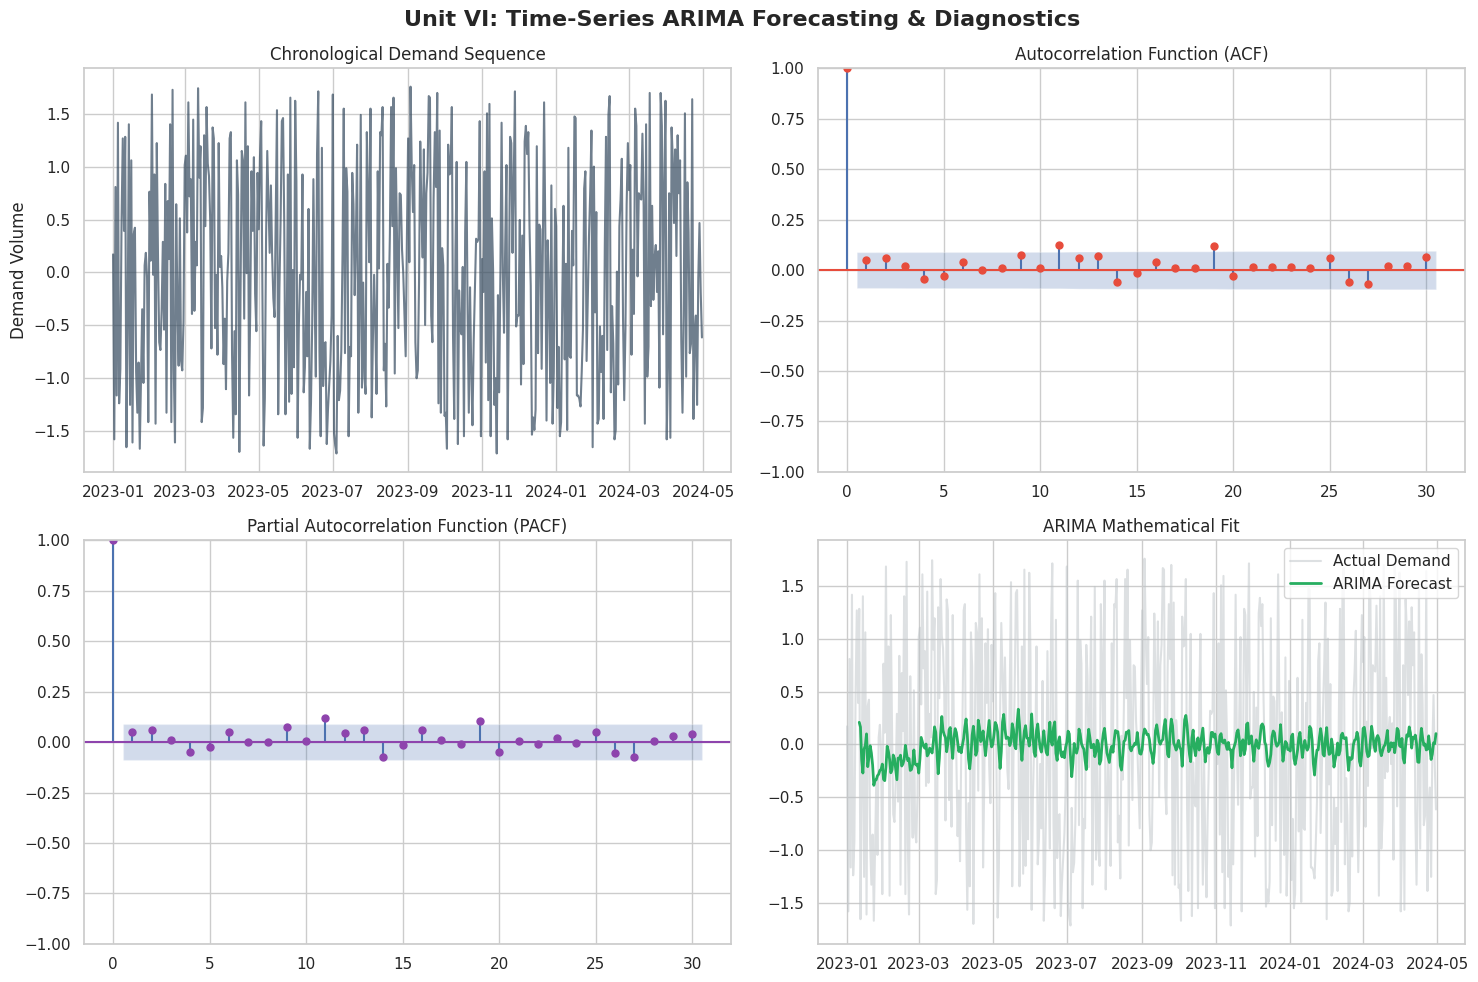

✓ Time-Series Diagnostics generated.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Unit VI: Time-Series ARIMA Forecasting & Diagnostics", fontsize=16, fontweight='bold')

axes[0, 0].plot(ts_data.index, ts_data, color='#34495E', alpha=0.7)
axes[0, 0].set_title("Chronological Demand Sequence")
axes[0, 0].set_ylabel("Demand Volume")

plot_acf(ts_data, ax=axes[0, 1], lags=30, color='#E74C3C')
axes[0, 1].set_title("Autocorrelation Function (ACF)")

plot_pacf(ts_data, ax=axes[1, 0], lags=30, color='#8E44AD')
axes[1, 0].set_title("Partial Autocorrelation Function (PACF)")

axes[1, 1].plot(ts_data.index, ts_data, label='Actual Demand', color='#BDC3C7', alpha=0.5)
axes[1, 1].plot(df.index, df['ARIMA_Forecast'], label='ARIMA Forecast', color='#27AE60', linewidth=2)
axes[1, 1].set_title("ARIMA Mathematical Fit")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../assets/unit6_time_series_arima.png', bbox_inches='tight')
plt.show()
print("✓ Time-Series Diagnostics generated.")